In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def build_unet(input_shape=(128, 128, 3)):
    inputs = layers.Input(input_shape)

    # Encoder (Downsampling)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Bridge
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)

    # Decoder (Upsampling) + Skip Connections
    u4 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c3)
    u4 = layers.concatenate([u4, c2])
    c4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u4)

    u5 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = layers.concatenate([u5, c1])
    c5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u5)

    # Output Layer (Sigmoid for binary mask)
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c5)

    return models.Model(inputs, outputs)

In [3]:
# --- 2. CREATE SYNTHETIC DATA (For Demonstration) ---
# In a real project, you would load images and their corresponding masks here.
def generate_dummy_data(n=100):
    images = np.random.random((n, 128, 128, 3))
    # Creating a fake mask (a square in the middle)
    masks = np.zeros((n, 128, 128, 1))
    masks[:, 40:80, 40:80, 0] = 1
    return images, masks

x_train, y_train = generate_dummy_data(200)

In [4]:
# --- 3. COMPILE AND TRAIN ---
model = build_unet()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Starting training...")
history = model.fit(x_train, y_train, epochs=15, batch_size=16, validation_split=0.1)

Starting training...
Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8760 - loss: 0.4528 - val_accuracy: 0.9023 - val_loss: 0.3260
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.9023 - loss: 0.3262 - val_accuracy: 0.9023 - val_loss: 0.3164
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.9023 - loss: 0.3251 - val_accuracy: 0.9023 - val_loss: 0.3205
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.9023 - loss: 0.3132 - val_accuracy: 0.9023 - val_loss: 0.3216
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.9023 - loss: 0.3104 - val_accuracy: 0.9023 - val_loss: 1.2153
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.9023 - loss: 0.5523 - val_accuracy: 0.9023 - val_loss: 0.3047
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.9023 - loss: 0.4406 - val_accuracy: 0.9023 - val_loss: 0.3355
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.9023 - loss: 0.3271 - va

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


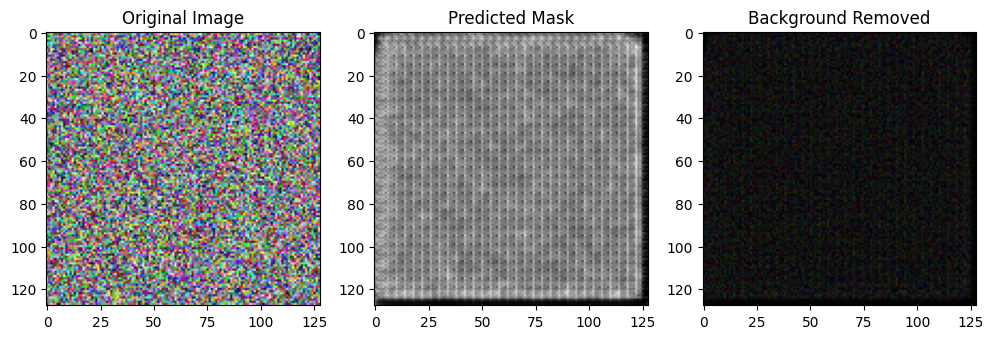

In [5]:
# --- 4. VISUALIZE RESULTS ---
def plot_results(model, x_test):
    preds = model.predict(x_test[:1])

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(x_test[0])

    plt.subplot(1, 3, 2)
    plt.title("Predicted Mask")
    plt.imshow(preds[0].reshape(128, 128), cmap='gray')

    plt.subplot(1, 3, 3)
    plt.title("Background Removed")
    # Multiply image by mask to keep only the foreground
    removed = x_test[0] * preds[0]
    plt.imshow(removed)
    plt.show()

plot_results(model, x_train)

In [8]:
# Force a stable Pillow version and update transformers
!pip install "pillow<11.0" transformers torch torchvision requests --quiet

print("✅ Installation complete. NOW RESTART YOUR RUNTIME (Runtime > Restart session) before running the next cell!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 71.5 MB/s eta 0:00:00
✅ Installation complete. NOW RESTART YOUR RUNTIME (Runtime > Restart session) before running the next cell!


In [1]:
import torch
import numpy as np
import requests
import matplotlib.pyplot as plt
from PIL import Image
import io

# 1. Load the Processor and Model
from transformers import AutoImageProcessor, MaskRCNNForObjectDetection

model_name = "facebook/maskrcnn-resnet50-fpn"
# We use 'cuda' if a GPU is available for much faster processing
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(model_name)
model = MaskRCNNForObjectDetection.from_pretrained(model_name).to(device)

# 2. Load and prepare the image
url = "https://images.pexels.com/photos/1108099/pexels-photo-1108099.jpeg"
response = requests.get(url)
image = Image.open(io.BytesIO(response.content)).convert("RGB")

inputs = processor(images=image, return_tensors="pt").to(device)

# 3. Inference
with torch.no_grad():
    outputs = model(**inputs)

# 4. Post-process (Get masks)
# threshold=0.7 is a good balance for background removal
target_sizes = torch.tensor([image.size[::-1]])
results = processor.post_process_instance_segmentation(outputs, threshold=0.7, target_sizes=target_sizes)[0]

# 5. Create the background removal effect
if len(results["masks"]) > 0:
    # Combine all masks into one (logical OR)
    # We move back to CPU for numpy operations
    combined_mask = torch.any(results["masks"], dim=0).cpu().numpy()

    img_array = np.array(image)
    bg_removed = img_array.copy()

    # Set pixels where mask is False (background) to 0 (black)
    bg_removed[~combined_mask] = [0, 0, 0]

    # Visualization
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.imshow(image); plt.title("Original")
    plt.subplot(1, 3, 2); plt.imshow(combined_mask, cmap='gray'); plt.title("Mask")
    plt.subplot(1, 3, 3); plt.imshow(bg_removed); plt.title("BG Removed")
    plt.show()
else:
    print("No objects detected above the threshold.")

ImportError: cannot import name 'MaskRCNNForObjectDetection' from 'transformers' (/usr/local/lib/python3.12/dist-packages/transformers/__init__.py)